# 🎮 Video Games Sales (1980–2024) — Análisis Exploratorio
Dataset con ventas globales de videojuegos por consola, género, publisher y región.

## 1. Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 2. Cargar datos

In [3]:
df_raw = pd.read_csv('videogames.csv')
print(f'Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}')
df_raw.head()

Filas: 64,016 | Columnas: 14


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17/09/2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18/11/2014,03/01/2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28/10/2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17/09/2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06/11/2015,14/01/2018


In [4]:
# Vista rápida de nulos
nulos = pd.DataFrame({
    'Nulos': df_raw.isnull().sum(),
    '% Nulos': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
nulos[nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

,Nulos,% Nulos
critic_score,57338,89.57
jp_sales,57290,89.49
na_sales,51379,80.26
pal_sales,51192,79.97
other_sales,48888,76.37
last_update,46137,72.07
total_sales,45094,70.44
release_date,7051,11.01
developer,17,0.03


## 3. Limpieza de datos

In [5]:
df = df_raw.copy()

# 1. Eliminar columnas sin valor analítico
df.drop(columns=['img', 'last_update'], inplace=True)

# 2. Fechas y año
df['release_date'] = pd.to_datetime(df['release_date'], format='%d/%m/%Y', errors='coerce')
df['year'] = df['release_date'].dt.year
df = df[df['year'].between(1980, 2024)]

# 3. Ventas regionales: nulo = 0 (sin registro en esa región)
sales_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df[sales_cols] = df[sales_cols].fillna(0)

# 4. Reconstruir total_sales donde sea posible
mask = df['total_sales'].isna()
df.loc[mask, 'total_sales'] = df.loc[mask, sales_cols].sum(axis=1)

# 5. Eliminar filas sin ningún dato de ventas
df = df[df['total_sales'] > 0].copy()

# 6. Developer: los pocos nulos como 'Unknown'
df['developer'] = df['developer'].fillna('Unknown')

# 7. critic_score: dejar como está (se usa en subconjunto)
df_scored = df[df['critic_score'].notna()].copy()

print(f'Dataset limpio: {df.shape[0]:,} filas | {df.shape[1]} columnas')
print(f'Subconjunto con critic_score: {df_scored.shape[0]:,} filas')
df.head()

Dataset limpio: 17,497 filas | 13 columnas
Subconjunto con critic_score: 3,977 filas


,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002.0
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013.0
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015.0


In [6]:
# Guardar dataset limpio
df.to_csv('video_games_clean.csv', index=False)
print('💾 video_games_clean.csv guardado')

💾 video_games_clean.csv guardado


## 4. Ventas globales por año

In [6]:
ventas_anio = df.groupby('year')['total_sales'].sum().reset_index()

fig = px.area(
    ventas_anio, x='year', y='total_sales',
    title='📈 Ventas globales totales por año (millones de unidades)',
    labels={'year': 'Año', 'total_sales': 'Ventas (M unidades)'},
    color_discrete_sequence=['#6c63ff']
)
fig.update_layout(hovermode='x unified')
fig.show()

## 5. Top géneros por ventas

In [7]:
generos = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False).reset_index()

fig = px.bar(
    generos, x='total_sales', y='genre', orientation='h',
    title='🎯 Ventas totales por género',
    labels={'total_sales': 'Ventas (M unidades)', 'genre': 'Género'},
    color='total_sales', color_continuous_scale='Viridis'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

## 6. Top consolas por ventas

In [8]:
consolas = df.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(15).reset_index()

fig = px.bar(
    consolas, x='console', y='total_sales',
    title='🕹️ Top 15 consolas por ventas totales',
    labels={'console': 'Consola', 'total_sales': 'Ventas (M unidades)'},
    color='total_sales', color_continuous_scale='Plasma'
)
fig.show()

## 7. Top publishers

In [9]:
publishers = (
    df[df['publisher'] != 'Unknown']
    .groupby('publisher')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)

fig = px.pie(
    publishers, names='publisher', values='total_sales',
    title='🏢 Top 12 Publishers por ventas totales',
    hole=0.4
)
fig.show()

## 8. Distribución regional de ventas

In [10]:
regiones = {
    'Norteamérica': df['na_sales'].sum(),
    'Europa/PAL': df['pal_sales'].sum(),
    'Japón': df['jp_sales'].sum(),
    'Otras regiones': df['other_sales'].sum()
}

fig = px.pie(
    names=list(regiones.keys()),
    values=list(regiones.values()),
    title='🌍 Distribución de ventas por región',
    color_discrete_sequence=px.colors.qualitative.Set2,
    hole=0.35
)
fig.show()

## 9. Evolución de géneros a lo largo del tiempo

In [11]:
top_generos = df.groupby('genre')['total_sales'].sum().nlargest(6).index.tolist()
evolucion = (
    df[df['genre'].isin(top_generos)]
    .groupby(['year', 'genre'])['total_sales']
    .sum()
    .reset_index()
)

fig = px.line(
    evolucion, x='year', y='total_sales', color='genre',
    title='📊 Evolución de ventas por género (Top 6)',
    labels={'year': 'Año', 'total_sales': 'Ventas (M)', 'genre': 'Género'}
)
fig.update_layout(hovermode='x unified')
fig.show()

## 10. Correlación: Crítica vs Ventas

In [12]:
fig = px.scatter(
    df_scored, x='critic_score', y='total_sales',
    color='genre', hover_data=['title', 'console', 'publisher'],
    title='⭐ Puntuación de crítica vs Ventas totales',
    labels={'critic_score': 'Puntuación crítica', 'total_sales': 'Ventas (M unidades)'},
    opacity=0.6, trendline='ols'
)
fig.show()

corr = df_scored[['critic_score', 'total_sales']].corr().iloc[0, 1]
print(f'Correlación Pearson: {corr:.3f}')

Correlación Pearson: 0.288


## 11. Top 20 juegos más vendidos

In [13]:
top20 = df.nlargest(20, 'total_sales')[['title', 'console', 'genre', 'publisher', 'year', 'total_sales']]

fig = px.bar(
    top20.sort_values('total_sales'), x='total_sales', y='title', orientation='h',
    color='genre', hover_data=['console', 'publisher', 'year'],
    title='🏆 Top 20 juegos más vendidos de la historia',
    labels={'total_sales': 'Ventas (M unidades)', 'title': ''}
)
fig.update_layout(height=600, showlegend=True)
fig.show()

## 12. Heatmap: Géneros por consola

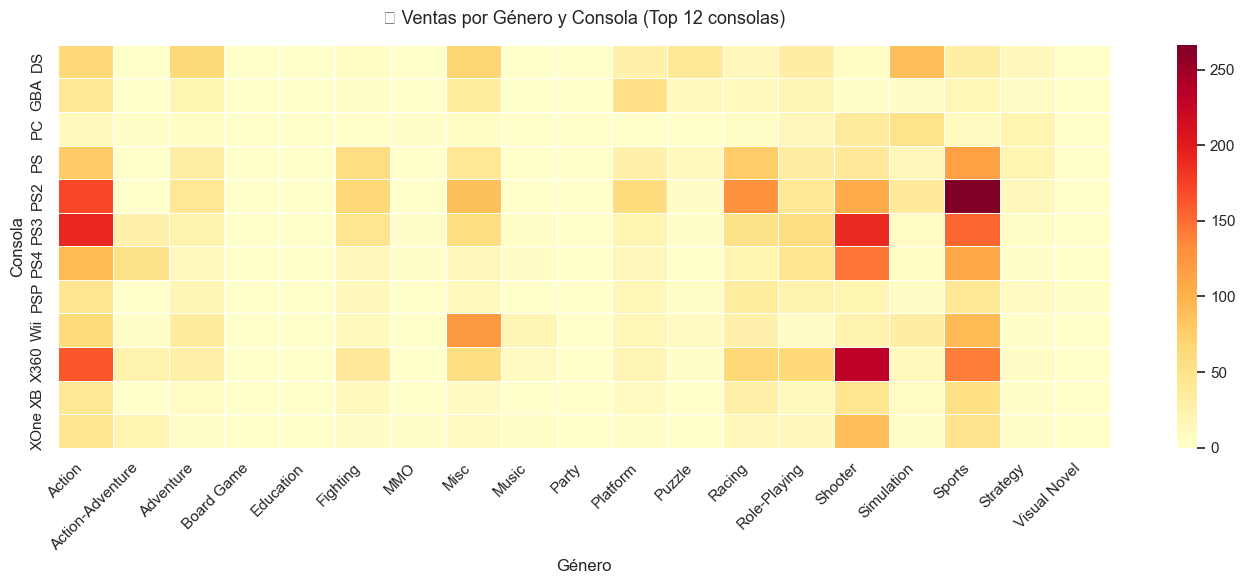

In [14]:
top_consolas = df.groupby('console')['total_sales'].sum().nlargest(12).index
heatmap_data = (
    df[df['console'].isin(top_consolas)]
    .groupby(['console', 'genre'])['total_sales']
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=False, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('🔥 Ventas por Género y Consola (Top 12 consolas)', fontsize=13, pad=15)
plt.xlabel('Género')
plt.ylabel('Consola')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 13. Resumen estadístico final

In [15]:
print('=' * 50)
print('📋 RESUMEN GENERAL DEL DATASET LIMPIO')
print('=' * 50)
print(f"Total juegos analizados:       {len(df):,}")
print(f"Período:                       {int(df['year'].min())} – {int(df['year'].max())}")
print(f"Consolas distintas:            {df['console'].nunique()}")
print(f"Géneros distintos:             {df['genre'].nunique()}")
print(f"Publishers distintos:          {df['publisher'].nunique()}")
print(f"Ventas totales globales:       {df['total_sales'].sum():,.1f} M unidades")
print(f"Juego más vendido:             {df.loc[df['total_sales'].idxmax(), 'title']} ({df['total_sales'].max():.1f} M)")
print(f"Género más vendido:            {df.groupby('genre')['total_sales'].sum().idxmax()}")
print(f"Consola más vendida:           {df.groupby('console')['total_sales'].sum().idxmax()}")
print('=' * 50)

📋 RESUMEN GENERAL DEL DATASET LIMPIO
Total juegos analizados:       17,497
Período:                       1980 – 2020
Consolas distintas:            39
Géneros distintos:             20
Publishers distintos:          672
Ventas totales globales:       6,594.1 M unidades
Juego más vendido:             Grand Theft Auto V (20.3 M)
Género más vendido:            Sports
Consola más vendida:           PS2
